# Common Libraries

In [1]:
import os, sys, shutil
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
from matplotlib.gridspec import GridSpec
from ipywidgets import interact, IntSlider, FloatSlider

if shutil.which("nvidia-smi") is not None:
    os.environ["MUJOCO_GL"] = "egl"
import mujoco

# Custom Libraries

In [2]:
sys.path.append("/home/seojin/Seojin_commonTool/Module")
from biomechanics_util import get_mujoco_joints, get_simulated_img, get_dependent_joints

# Params

In [3]:
model_path = "/mnt/sdb2/DeepProprioception/Projects/DP01_mri/Myosuite/Model/scaled_model_cvt3_mocap.xml"
qpos_data_path = "/mnt/sdb2/DeepProprioception/Projects/DP01_mri/Myosuite/Model/IK_files/trial1_IK_qpos.csv"

target_joint_name = "shoulder_elv"

# Initialize model

In [4]:
model = mujoco.MjModel.from_xml_path(model_path)
mj_data = mujoco.MjData(model)

qpos_data = pd.read_csv(qpos_data_path, index_col = 0)

# Load data

In [5]:
# Joint
joint_names = [mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_JOINT, idx) for idx in range(model.njnt)]
dependent_joint_names, independent_joint_names = get_mujoco_joints(model_path)

# Renderer

In [6]:
# Renderer
renderer = mujoco.Renderer(model, height=400, width=600)
scene_option = mujoco.MjvOption()
scene_option.frame = mujoco.mjtFrame.mjFRAME_WORLD

# Camera
camera = mujoco.MjvCamera()
camera.azimuth = 0
camera.elevation = -110
camera.distance = 2.0

# Initialize model pose

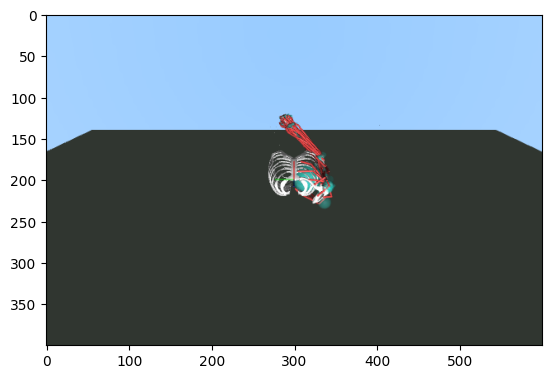

In [7]:
mj_data.qpos[:] = qpos_data.iloc[0].values
mujoco.mj_step(model, mj_data)

renderer.update_scene(mj_data, camera = camera, scene_option = scene_option)
plt.imshow(renderer.render())

# Move one joint

In [8]:
target_jid = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, target_joint_name)

dependent_joint_names = get_dependent_joints(model, target_joint_name)

target_joint_angles = np.arange(0, 1, 0.005)
interest_joint_names = [target_joint_name] + dependent_joint_names
joint_angles = pd.DataFrame(np.zeros((len(target_joint_angles), len(interest_joint_names))))
joint_angles.columns = interest_joint_names
joint_angles[target_joint_name] = target_joint_angles

def show_frame(frame_i = 0):
    # Set pose
    target_qaddr = model.jnt_qposadr[target_jid]
    mj_data.qpos[target_qaddr] = joint_angles.loc[frame_i, target_joint_name]
    
    # Make pose depedend on the target pose with only considering geometric constraint 
    mujoco.mj_fwdPosition(model, mj_data)
    
    # Record joint angle on the current pose
    for idx, joint_name in enumerate(interest_joint_names):
        jid = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, joint_name)
        qaddr = model.jnt_qposadr[jid]
        joint_angles.loc[frame_i, joint_name] = mj_data.qpos[qaddr]
        
    # Image
    renderer.update_scene(mj_data, camera=camera, scene_option=scene_option)
    n_interest_joint = len(interest_joint_names)
    n_col = 4
    n_row = (n_interest_joint // n_col) + 2
    
    fig = plt.figure(figsize=(14, 3 * n_row))
    gs = GridSpec(n_row, n_col, figure=fig)
    
    ax_img = fig.add_subplot(gs[0, :])
    ax_img.imshow(renderer.render())
    ax_img.axis("off")

    # Joint angle history plot
    for idx, joint_name in enumerate(interest_joint_names):
        row = (idx // n_col) + 1
        col = idx % n_col
        
        ax = fig.add_subplot(gs[row, col])
        ax.plot(joint_angles.loc[:frame_i, joint_name], color='steelblue', lw=2)
        ax.set_title(f"{joint_name}", fontsize=10)
        ax.set_ylim([-1.0, 1.0]) 
        ax.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

interact(show_frame, frame_i = (0, len(joint_angles) - 1))

interactive(children=(IntSlider(value=0, description='frame_i', max=199), Output()), _dom_classes=('widget-int…

<function __main__.show_frame(frame_i=0)>